## Regression Problem


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_regression
x,y = make_regression(n_samples=50,n_features=5,n_informative=2,random_state=0)

In [3]:
x = pd.DataFrame(x)
x.head()

,0,1,2,3,4
0,0.316943,0.844363,-1.000215,1.188030,-1.544771
1,-0.694568,0.376426,-1.099401,1.326386,0.298238
2,-0.042257,-0.410050,-0.017020,2.259309,0.379152
3,-1.225436,-0.498032,1.929532,0.087551,0.949421
4,-0.268003,1.867559,0.906045,1.910065,-0.861226


In [4]:
y[:5]

array([-63.57581583, -79.87377127,  -8.77022673, 143.13047845,
       105.2767551 ])

In [6]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest

In [16]:
fs = SelectKBest(score_func=mutual_info_regression,k=2)
fs.fit(x,y)

SelectKBest(k=2,
            score_func=<function mutual_info_regression at 0x00000270D0D504A0>)

In [17]:
fs.scores_

array([0.        , 0.01040974, 1.26950743, 0.        , 0.        ])

In [18]:
mi_score = pd.Series(fs.scores_,index=x.columns)
mi_score

0    0.000000
1    0.010410
2    1.269507
3    0.000000
4    0.000000
dtype: float64

<Axes: >

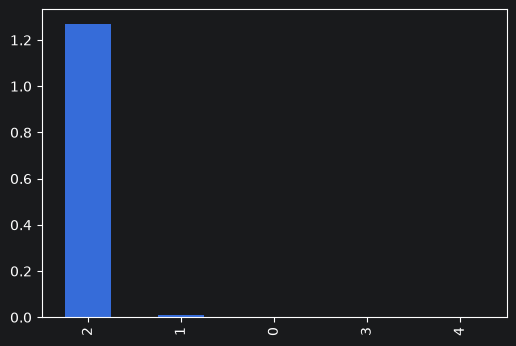

In [19]:
mi_score.sort_values(ascending=False).plot.bar(figsize=(6,4))

In [20]:
x_selected = fs.fit_transform(x,y)
x_selected = pd.DataFrame(x_selected)

In [21]:
x_selected.head()

,0,1
0,0.844363,-1.000215
1,0.376426,-1.099401
2,-0.410050,-0.017020
3,-0.498032,1.929532
4,1.867559,0.906045


,0,1,2,3,4
0,0.316943,0.844363,-1.000215,1.188030,-1.544771
1,-0.694568,0.376426,-1.099401,1.326386,0.298238
2,-0.042257,-0.410050,-0.017020,2.259309,0.379152
3,-1.225436,-0.498032,1.929532,0.087551,0.949421
4,-0.268003,1.867559,0.906045,1.910065,-0.861226


## Classification Problem


In [29]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif

In [30]:
x,y = make_classification(n_samples=50,n_features=5,n_informative=2,random_state=0)
x = pd.DataFrame(x)

In [31]:
x.head()

,0,1,2,3,4
0,0.708792,0.208081,0.087551,0.949577,1.311943
1,0.312175,0.330009,0.576591,-0.295483,-0.322081
2,0.519436,0.115573,-1.147469,0.806438,1.100837
3,-0.521531,-0.298091,0.407462,-0.264591,-0.417969
4,1.007455,1.062387,0.539249,-0.945734,-1.029523


In [32]:
y[:5]

array([1, 1, 1, 0, 1])

<Axes: >

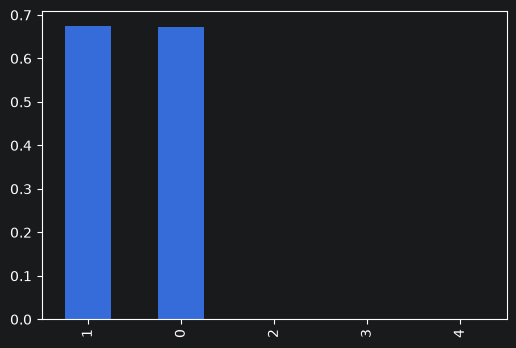

In [33]:
fs = SelectKBest(score_func=mutual_info_classif,k=3)
fs.fit(x,y)
mi_score = pd.Series(fs.scores_,index=x.columns)
mi_score.sort_values(ascending=False).plot.bar(figsize=(6,4))

In [34]:
selected_X = fs.fit_transform(x,y)
selected_X = pd.DataFrame(selected_X)
selected_X.head()

,0,1,2
0,0.708792,0.208081,1.311943
1,0.312175,0.330009,-0.322081
2,0.519436,0.115573,1.100837
3,-0.521531,-0.298091,-0.417969
4,1.007455,1.062387,-1.029523
